# NIFTY Premium Variance: Implied vs Historical Volatility

**The question:** how much of a NIFTY option's price exists purely because
implied volatility differs from historical volatility — and *why* does that gap
exist at all?

## The decomposition

An option's price is a function of volatility. Feed Black-76 two different
volatilities and the difference in price is the premium attributable to the
volatility gap:

$$\text{premium}_{IV} = \text{Black76}(F, K, T, r, \sigma_{IV}) \qquad
  \text{premium}_{HV} = \text{Black76}(F, K, T, r, \sigma_{HV})$$

$$\boxed{\text{premium variance} = \text{premium}_{IV} - \text{premium}_{HV}}$$

For an at-the-money-forward straddle the price is very close to
$0.7979 \cdot F \cdot \sigma \sqrt{T}$ — **linear in volatility**. So the
premium variance is almost exactly

$$\text{vega} \times (\sigma_{IV} - \sigma_{HV})$$

We verify that linearity below rather than assuming it.

## Three volatilities, never mixed

| | What it is | Known when? |
|---|---|---|
| **IV** | Implied, backed out of NSE settle prices | At trade time |
| **HV** | Historical, from the *N* days before | At trade time |
| **RV** | Realized, over the option's actual life | **Only afterwards** |

`IV − HV` is the question asked here, and it is tradeable.
`IV − RV` is the true *variance risk premium* — it says whether the price was
right, but using it as a signal is lookahead bias. Both are computed; they never
share a column.

## Method notes

- **Black-76 on futures**, not Black-Scholes on spot. The NIFTY future already
  prices in carry and dividends, so using it as the forward removes a
  dividend-yield assumption instead of guessing one.
- **ATM IV by interpolating the smile to log(K/F) = 0.** Averaging strikes
  either side of the forward would import NIFTY's put skew into the ATM number
  and overstate the premium.
- **Yang–Zhang** is the default historical estimator because it handles
  overnight gaps, which NIFTY produces routinely. Other estimators are compared
  below — the choice moves the answer materially.
- **Lot size comes from NSE per-day**, not a constant: it changed during the
  sample, and a hardcoded value would misstate every rupee figure.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import black76 as b76
import volatility as vol
import variance_premium as vp

plt.rcParams.update({
    "figure.figsize": (13, 5.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

C_IV, C_HV, C_GAP, C_RV = "#C44E52", "#4C72B0", "#DD8452", "#55A868"

df = pd.read_csv("out/premium_variance.csv", parse_dates=["date", "expiry"])
df = df.sort_values("date").reset_index(drop=True)
print(f"{len(df):,} observations   {df.date.min():%Y-%m-%d} to {df.date.max():%Y-%m-%d}")
print(f"median days to expiry: {df.dte.median():.0f}")
df.head(3)

1,128 observations   2022-01-03 to 2026-07-30
median days to expiry: 29


,date,expiry,dte,T_years,spot,forward,atm_strike,basis_pct,iv,hv,...,premium_variance_rupees,straddle_at_iv_rupees,hv_close_to_close,hv_parkinson,hv_garman_klass,hv_yang_zhang,rv_forward,straddle_at_rv,vrp_vol_points,vrp_rupees
0,2022-01-03,2022-02-03,31,0.084932,17625.699219,17723.15,17700.0,0.552890,0.218928,0.166368,...,16134.606952,67253.369165,0.186810,0.147554,0.143758,0.166368,0.169303,693.597773,0.049625,15233.536184
1,2022-01-04,2022-02-03,30,0.082192,17805.250000,17889.95,17900.0,0.475702,0.218752,0.158697,...,18331.205650,66792.169785,0.182499,0.138465,0.136467,0.158697,0.171506,698.279606,0.047246,14421.199356
2,2022-01-05,2022-02-03,29,0.079452,17925.250000,18009.25,18000.0,0.468613,0.198737,0.159376,...,11887.887693,60039.308485,0.184869,0.138283,0.136083,0.159376,0.172765,695.936969,0.025973,7844.035777


## 1. Headline numbers

In [2]:
print(vp.summarise(df))

rows: 1128   2022-01-03 -> 2026-07-30
median DTE: 29 days

implied vol      mean 15.19%   median 14.25%
historical vol   mean 13.48%   median 12.35%
IV - HV          mean +1.71%   median +1.92%
  IV above HV on 77.6% of days

ATM straddle at IV   mean    720.6 pts
ATM straddle at HV   mean    646.6 pts
premium variance     mean    +74.0 pts (+10.6% of the premium)
                     mean Rs +5,380 per lot

--- hindsight, on the 1125 rows whose life has completed ---
realized vol over life  mean 12.80%
IV - RV (true VRP)      mean +2.39%
  IV exceeded RV on 78.6% of days
  mean Rs +7,679 per lot to a straddle seller (before costs and slippage)


In [3]:
summary = pd.DataFrame({
    "Implied vol (IV)":        df.iv.describe(),
    "Historical vol (HV)":     df.hv.describe(),
    "Gap (IV - HV)":           df.iv_minus_hv.describe(),
    "Realized vol (RV, fwd)":  df.rv_forward.describe(),
}).T[["mean", "50%", "std", "min", "max"]]
summary.columns = ["mean", "median", "std dev", "min", "max"]
(summary * 100).round(2).style.format("{:.2f}%").set_caption("Volatility, annualised (%)")

,mean,median,std dev,min,max
Implied vol (IV),15.19%,14.25%,3.72%,8.63%,27.70%
Historical vol (HV),13.48%,12.35%,4.64%,6.87%,26.47%
Gap (IV - HV),1.71%,1.92%,3.81%,-10.71%,11.80%
"Realized vol (RV, fwd)",12.80%,11.47%,5.38%,5.26%,32.53%


## 2. The two volatilities, side by side

The shaded band is the gap. Red above blue means options cost more than the
recent past would justify.

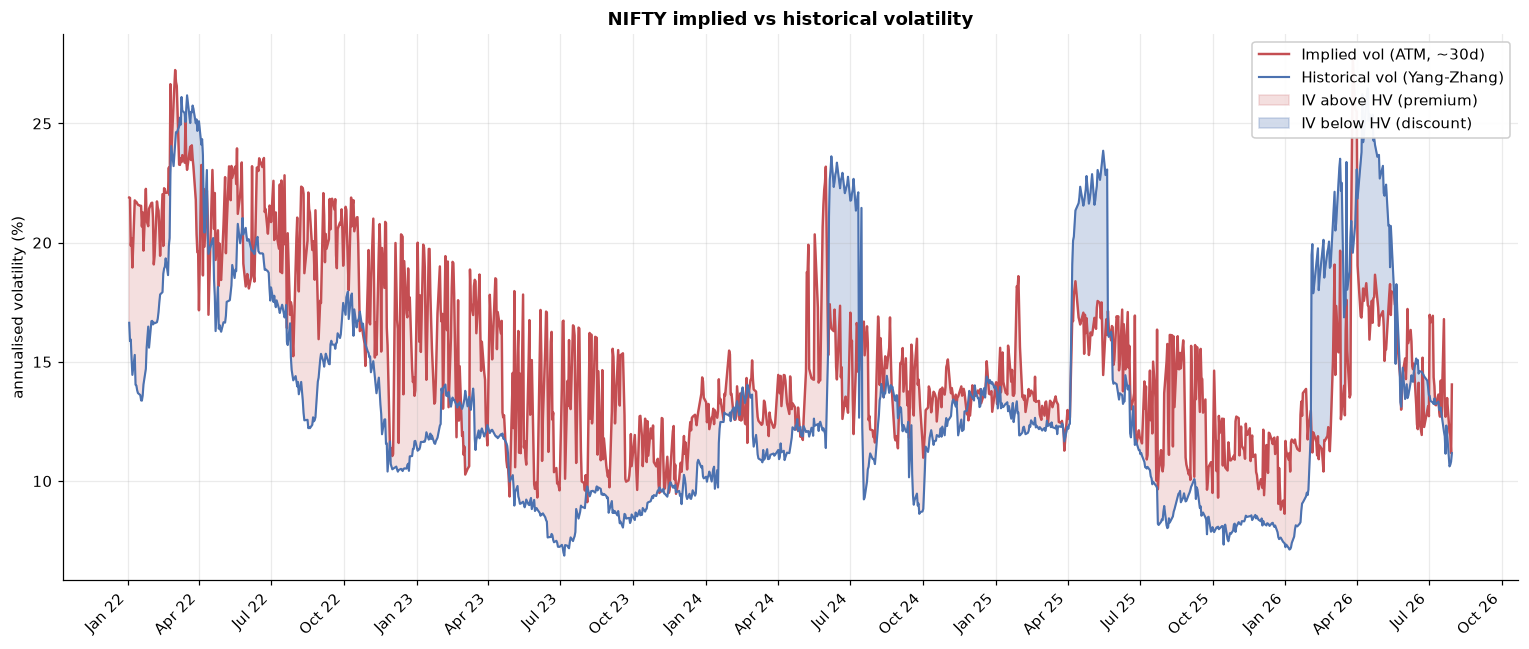

IV exceeded HV on 77.6% of days; mean gap +1.71 vol points


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.date, df.iv * 100, color=C_IV, lw=1.6, label="Implied vol (ATM, ~30d)")
ax.plot(df.date, df.hv * 100, color=C_HV, lw=1.4, label="Historical vol (Yang-Zhang)")
ax.fill_between(df.date, df.hv * 100, df.iv * 100, where=df.iv >= df.hv,
                color=C_IV, alpha=0.18, interpolate=True, label="IV above HV (premium)")
ax.fill_between(df.date, df.hv * 100, df.iv * 100, where=df.iv < df.hv,
                color=C_HV, alpha=0.25, interpolate=True, label="IV below HV (discount)")
ax.set_ylabel("annualised volatility (%)")
ax.set_title("NIFTY implied vs historical volatility")
ax.legend(loc="upper right", framealpha=0.95)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

pct_above = 100 * (df.iv_minus_hv > 0).mean()
print(f"IV exceeded HV on {pct_above:.1f}% of days; mean gap {df.iv_minus_hv.mean()*100:+.2f} vol points")

## 3. What the gap is worth in money

Same picture, priced. The straddle valued at implied vol vs the same straddle
valued at historical vol — the shaded area is the premium variance.

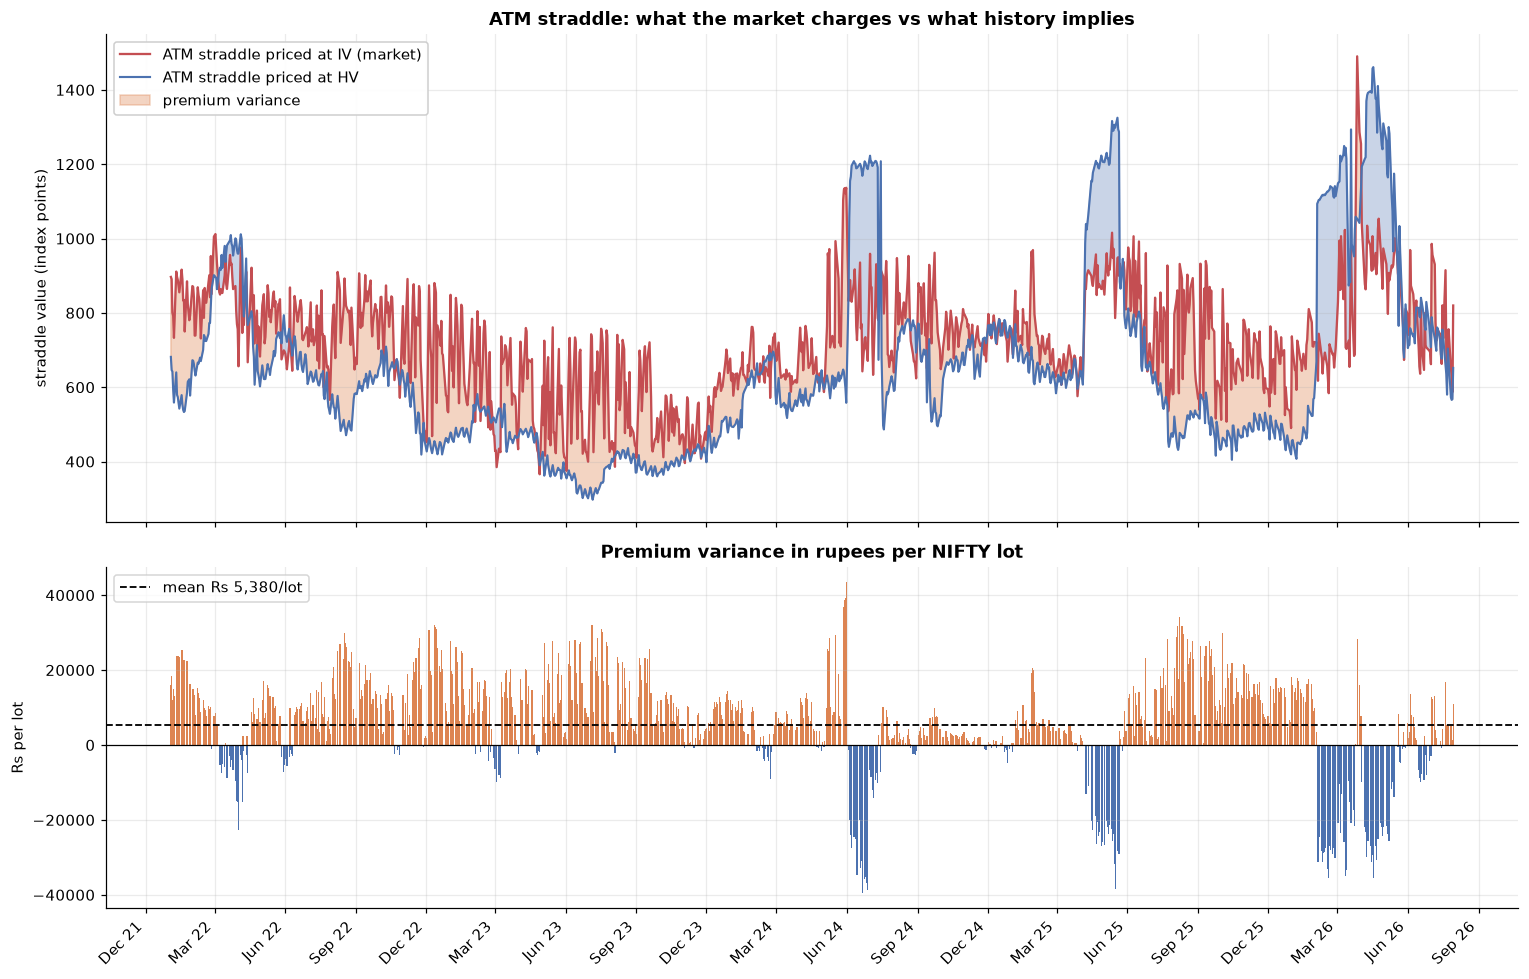

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.4]})

ax1.plot(df.date, df.straddle_at_iv, color=C_IV, lw=1.5, label="ATM straddle priced at IV (market)")
ax1.plot(df.date, df.straddle_at_hv, color=C_HV, lw=1.4, label="ATM straddle priced at HV")
ax1.fill_between(df.date, df.straddle_at_hv, df.straddle_at_iv,
                 where=df.straddle_at_iv >= df.straddle_at_hv,
                 color=C_GAP, alpha=0.35, interpolate=True, label="premium variance")
ax1.fill_between(df.date, df.straddle_at_hv, df.straddle_at_iv,
                 where=df.straddle_at_iv < df.straddle_at_hv,
                 color=C_HV, alpha=0.3, interpolate=True)
ax1.set_ylabel("straddle value (index points)")
ax1.set_title("ATM straddle: what the market charges vs what history implies")
ax1.legend(loc="upper left", framealpha=0.95)

colors = np.where(df.premium_variance_rupees >= 0, C_GAP, C_HV)
ax2.bar(df.date, df.premium_variance_rupees, color=colors, width=1.6)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(df.premium_variance_rupees.mean(), color="black", ls="--", lw=1.2,
            label=f"mean Rs {df.premium_variance_rupees.mean():,.0f}/lot")
ax2.set_ylabel("Rs per lot")
ax2.set_title("Premium variance in rupees per NIFTY lot")
ax2.legend(loc="upper left")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 4. Distribution of the gap

If the gap were noise it would centre on zero. It does not.

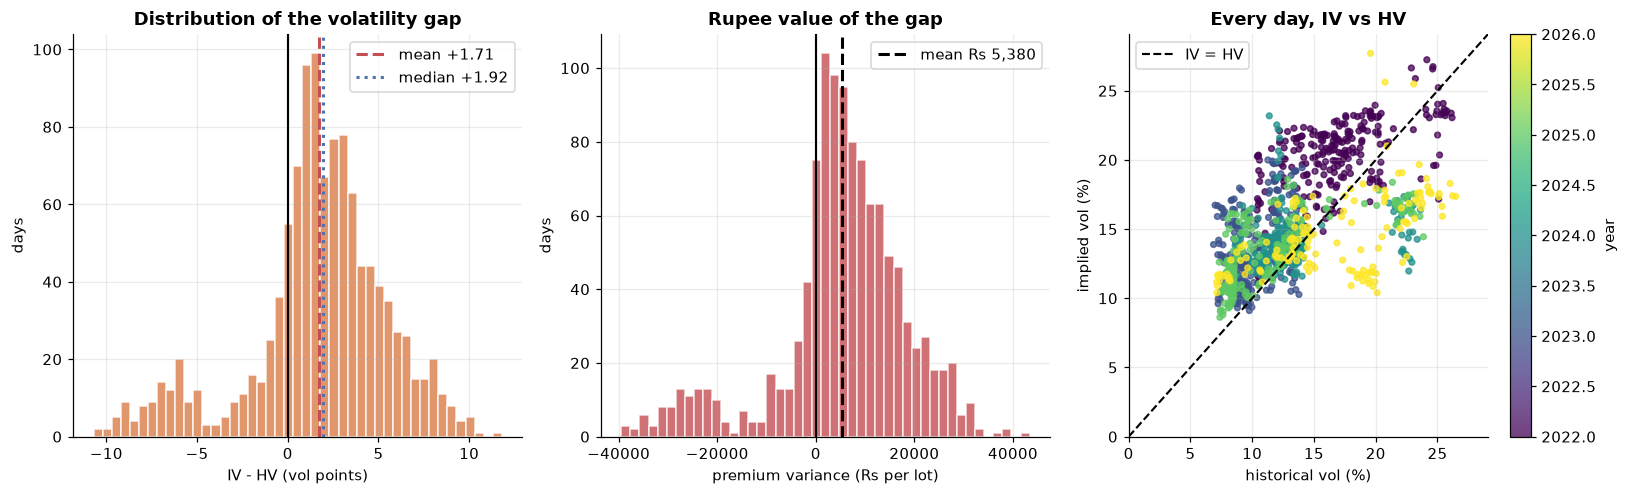

days IV > HV: 875 of 1128
gap skewness: -0.74   kurtosis: 0.91


In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.6))

gap = df.iv_minus_hv * 100
ax1.hist(gap, bins=45, color=C_GAP, alpha=0.85, edgecolor="white")
ax1.axvline(0, color="black", lw=1.4)
ax1.axvline(gap.mean(), color=C_IV, ls="--", lw=2, label=f"mean {gap.mean():+.2f}")
ax1.axvline(gap.median(), color=C_HV, ls=":", lw=2, label=f"median {gap.median():+.2f}")
ax1.set_xlabel("IV - HV (vol points)"); ax1.set_ylabel("days")
ax1.set_title("Distribution of the volatility gap"); ax1.legend()

rup = df.premium_variance_rupees
ax2.hist(rup, bins=45, color=C_IV, alpha=0.8, edgecolor="white")
ax2.axvline(0, color="black", lw=1.4)
ax2.axvline(rup.mean(), color="black", ls="--", lw=2, label=f"mean Rs {rup.mean():,.0f}")
ax2.set_xlabel("premium variance (Rs per lot)"); ax2.set_ylabel("days")
ax2.set_title("Rupee value of the gap"); ax2.legend()

sc = ax3.scatter(df.hv * 100, df.iv * 100, c=df.date.dt.year, cmap="viridis", s=14, alpha=0.75)
lims = [0, max(df.iv.max(), df.hv.max()) * 105]
ax3.plot(lims, lims, "k--", lw=1.4, label="IV = HV")
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xlabel("historical vol (%)"); ax3.set_ylabel("implied vol (%)")
ax3.set_title("Every day, IV vs HV"); ax3.legend()
plt.colorbar(sc, ax=ax3, label="year")
plt.tight_layout(); plt.show()

print(f"days IV > HV: {(df.iv_minus_hv > 0).sum()} of {len(df)}")
print(f"gap skewness: {gap.skew():.2f}   kurtosis: {gap.kurtosis():.2f}")

## 5. Why premium variance ≈ vega × gap

At the forward, a straddle's value is nearly linear in volatility, so the exact
Black-76 difference and the linear approximation should coincide. If they ever
diverge, convexity is doing something worth investigating.

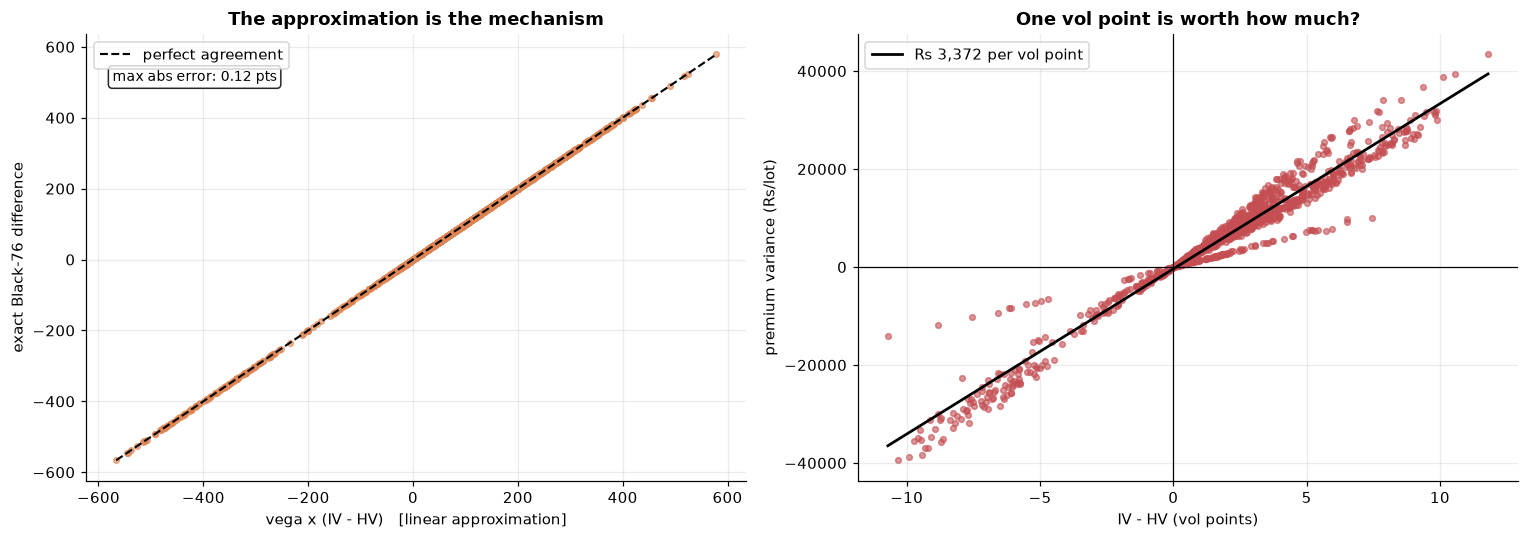

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df.vega_approx_pts, df.premium_variance_pts, s=14, alpha=0.6, color=C_GAP)
lo = min(df.vega_approx_pts.min(), df.premium_variance_pts.min())
hi = max(df.vega_approx_pts.max(), df.premium_variance_pts.max())
ax1.plot([lo, hi], [lo, hi], "k--", lw=1.4, label="perfect agreement")
ax1.set_xlabel("vega x (IV - HV)   [linear approximation]")
ax1.set_ylabel("exact Black-76 difference")
ax1.set_title("The approximation is the mechanism")
ax1.legend()
err = (df.premium_variance_pts - df.vega_approx_pts).abs()
ax1.text(0.04, 0.92, f"max abs error: {err.max():.2f} pts", transform=ax1.transAxes,
         fontsize=9, va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.85))

ax2.scatter(df.iv_minus_hv * 100, df.premium_variance_rupees, s=14, alpha=0.6, color=C_IV)
ax2.axhline(0, color="black", lw=0.8); ax2.axvline(0, color="black", lw=0.8)
ax2.set_xlabel("IV - HV (vol points)"); ax2.set_ylabel("premium variance (Rs/lot)")
ax2.set_title("One vol point is worth how much?")
fit = np.polyfit(df.iv_minus_hv * 100, df.premium_variance_rupees, 1)
xs = np.linspace((df.iv_minus_hv * 100).min(), (df.iv_minus_hv * 100).max(), 50)
ax2.plot(xs, np.polyval(fit, xs), color="black", lw=1.8,
         label=f"Rs {fit[0]:,.0f} per vol point")
ax2.legend()
plt.tight_layout(); plt.show()

## 6. Does the estimator choice change the story?

Yes, materially. A gap-blind estimator reads volatility low and therefore reads
the premium high. This is a modelling decision, not a market fact.

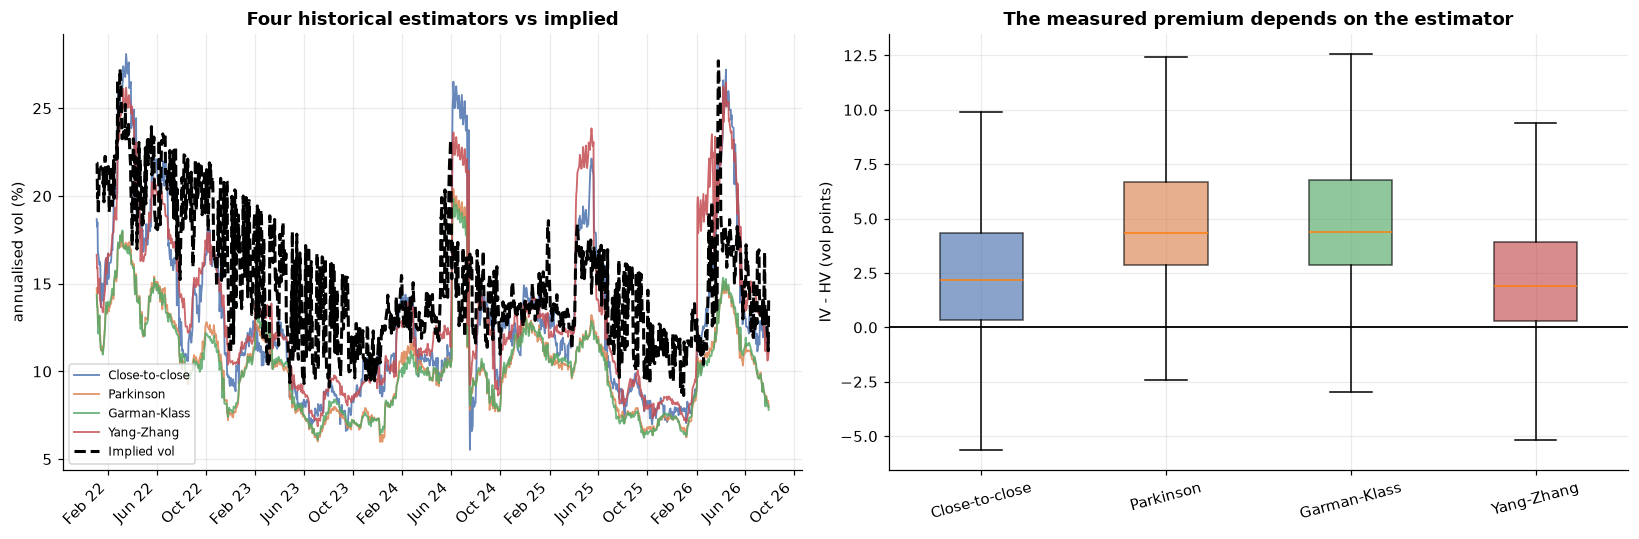

,mean HV (%),mean IV - HV (vol pts),implied premium (Rs/lot)
Close-to-close,13.09,2.10,6825.58
Parkinson,10.43,4.76,15375.39
Garman-Klass,10.40,4.79,15496.13
Yang-Zhang,13.48,1.71,5379.16


In [8]:
methods = ["hv_close_to_close", "hv_parkinson", "hv_garman_klass", "hv_yang_zhang"]
labels = ["Close-to-close", "Parkinson", "Garman-Klass", "Yang-Zhang"]
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for m, lab, c in zip(methods, labels, palette):
    ax1.plot(df.date, df[m] * 100, lw=1.2, label=lab, color=c, alpha=0.85)
ax1.plot(df.date, df.iv * 100, lw=2.0, color="black", ls="--", label="Implied vol")
ax1.set_ylabel("annualised vol (%)"); ax1.set_title("Four historical estimators vs implied")
ax1.legend(fontsize=8); ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

gaps = [(df.iv - df[m]) * 100 for m in methods]
bp = ax2.boxplot(gaps, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], palette):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax2.axhline(0, color="black", lw=1.2)
ax2.set_ylabel("IV - HV (vol points)")
ax2.set_title("The measured premium depends on the estimator")
plt.setp(ax2.get_xticklabels(), rotation=15)
plt.tight_layout(); plt.show()

comp = pd.DataFrame({
    "mean HV (%)": [df[m].mean() * 100 for m in methods],
    "mean IV - HV (vol pts)": [(df.iv - df[m]).mean() * 100 for m in methods],
    "implied premium (Rs/lot)": [((df.iv - df[m]) * df.straddle_vega * df.lot_size).mean() for m in methods],
}, index=labels).round(2)
comp

## 7. The gap is not constant — it depends on the volatility regime

Volatility mean-reverts. When realized volatility is unusually low, the market
prices reversion *upward*, so the gap is wide. When volatility has already
spiked, implied vol often sits *below* historical. This is the single most
useful structural fact in the whole notebook.

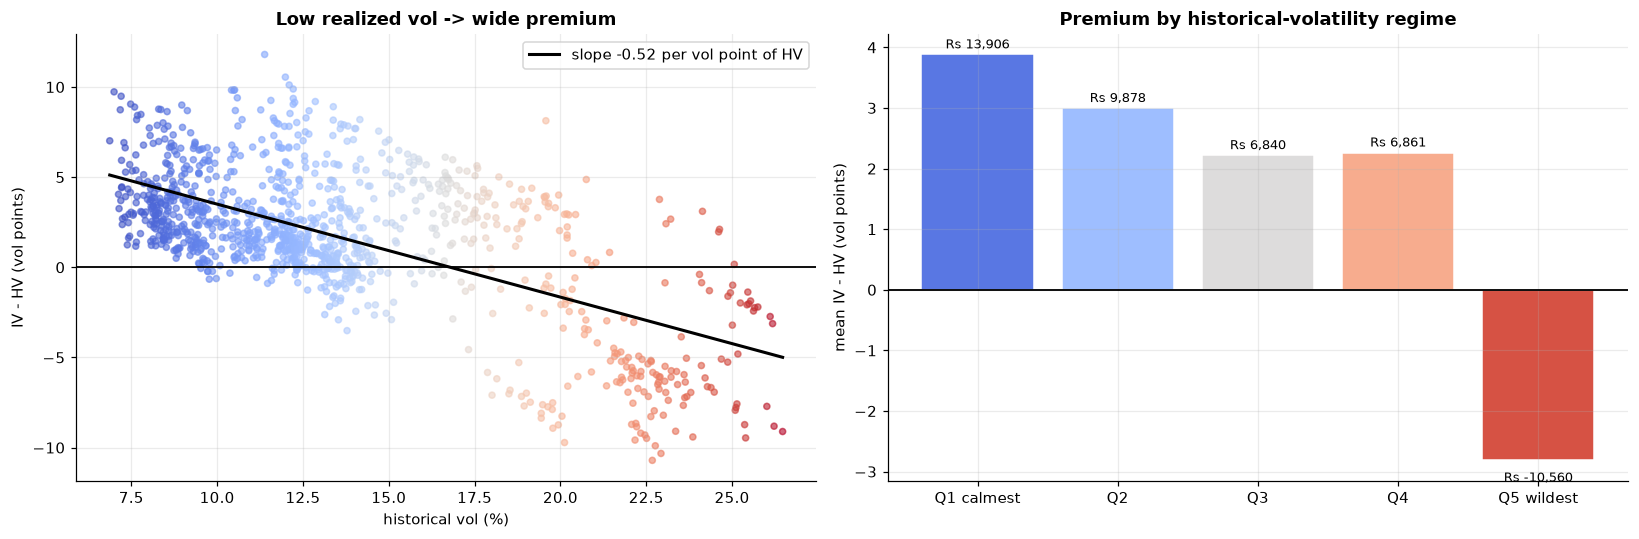

correlation between HV level and the gap: -0.628


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.scatter(df.hv * 100, df.iv_minus_hv * 100, s=16, alpha=0.6, c=df.hv * 100, cmap="coolwarm")
ax1.axhline(0, color="black", lw=1.2)
fit = np.polyfit(df.hv * 100, df.iv_minus_hv * 100, 1)
xs = np.linspace(df.hv.min() * 100, df.hv.max() * 100, 50)
ax1.plot(xs, np.polyval(fit, xs), "k-", lw=2,
         label=f"slope {fit[0]:.2f} per vol point of HV")
ax1.set_xlabel("historical vol (%)"); ax1.set_ylabel("IV - HV (vol points)")
ax1.set_title("Low realized vol -> wide premium"); ax1.legend()

df["hv_quintile"] = pd.qcut(df.hv, 5, labels=["Q1 calmest", "Q2", "Q3", "Q4", "Q5 wildest"])
by_q = df.groupby("hv_quintile", observed=True).agg(
    gap=("iv_minus_hv", "mean"), rupees=("premium_variance_rupees", "mean"))
bars = ax2.bar(by_q.index.astype(str), by_q.gap * 100,
               color=plt.cm.coolwarm(np.linspace(0.1, 0.9, len(by_q))), edgecolor="white")
ax2.axhline(0, color="black", lw=1.2)
ax2.set_ylabel("mean IV - HV (vol points)")
ax2.set_title("Premium by historical-volatility regime")
for b, (_, row) in zip(bars, by_q.iterrows()):
    ax2.text(b.get_x() + b.get_width() / 2,
             b.get_height() + (0.1 if b.get_height() >= 0 else -0.35),
             f"Rs {row.rupees:,.0f}", ha="center", fontsize=8.5)
plt.tight_layout(); plt.show()

corr = df.hv.corr(df.iv_minus_hv)
print(f"correlation between HV level and the gap: {corr:+.3f}")

## 8. Term structure: does the premium depend on time to expiry?

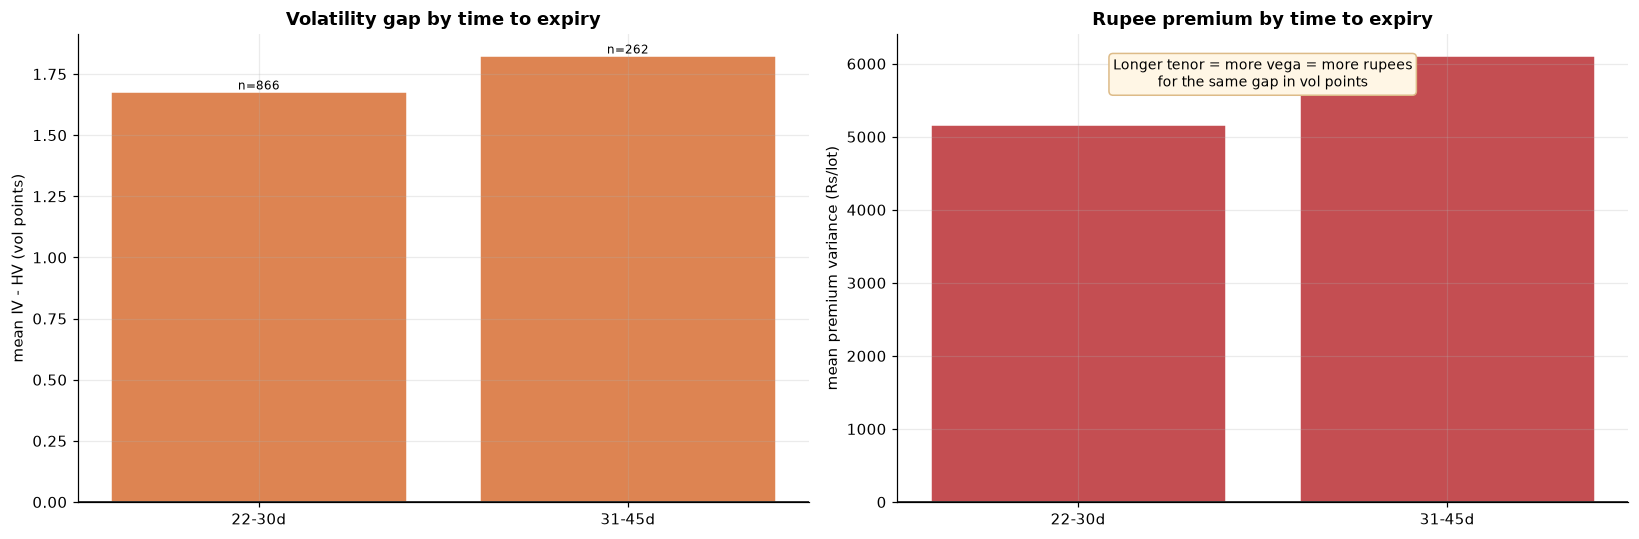

,gap,rupees,n
dte_bucket,,,
22-30d,0.0167,5161.7361,866
31-45d,0.0182,6099.4326,262


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

bins = [0, 7, 14, 21, 30, 45, 60, 400]
df["dte_bucket"] = pd.cut(df.dte, bins=bins,
                          labels=["<=7d", "8-14d", "15-21d", "22-30d", "31-45d", "46-60d", ">60d"])
by_dte = df.groupby("dte_bucket", observed=True).agg(
    gap=("iv_minus_hv", "mean"), rupees=("premium_variance_rupees", "mean"), n=("iv", "size"))
by_dte = by_dte[by_dte.n >= 5]

ax1.bar(by_dte.index.astype(str), by_dte.gap * 100, color=C_GAP, edgecolor="white")
ax1.axhline(0, color="black", lw=1.0)
ax1.set_ylabel("mean IV - HV (vol points)"); ax1.set_title("Volatility gap by time to expiry")
for i, (g, n) in enumerate(zip(by_dte.gap, by_dte.n)):
    ax1.text(i, g * 100, f"n={n}", ha="center", va="bottom", fontsize=8)

ax2.bar(by_dte.index.astype(str), by_dte.rupees, color=C_IV, edgecolor="white")
ax2.axhline(0, color="black", lw=1.0)
ax2.set_ylabel("mean premium variance (Rs/lot)")
ax2.set_title("Rupee premium by time to expiry")
ax2.text(0.5, 0.95,
         "Longer tenor = more vega = more rupees\nfor the same gap in vol points",
         transform=ax2.transAxes, ha="center", va="top", fontsize=9,
         bbox=dict(boxstyle="round", fc="#FFF6E5", ec="#DDBB88"))
plt.tight_layout(); plt.show()
by_dte.round(4)

## 9. Volatility cone — is today's implied vol actually high?

The cone shows where historical volatility has sat, by horizon. Implied vol
plotted on top shows whether the market is pricing something unusual or merely
normal.

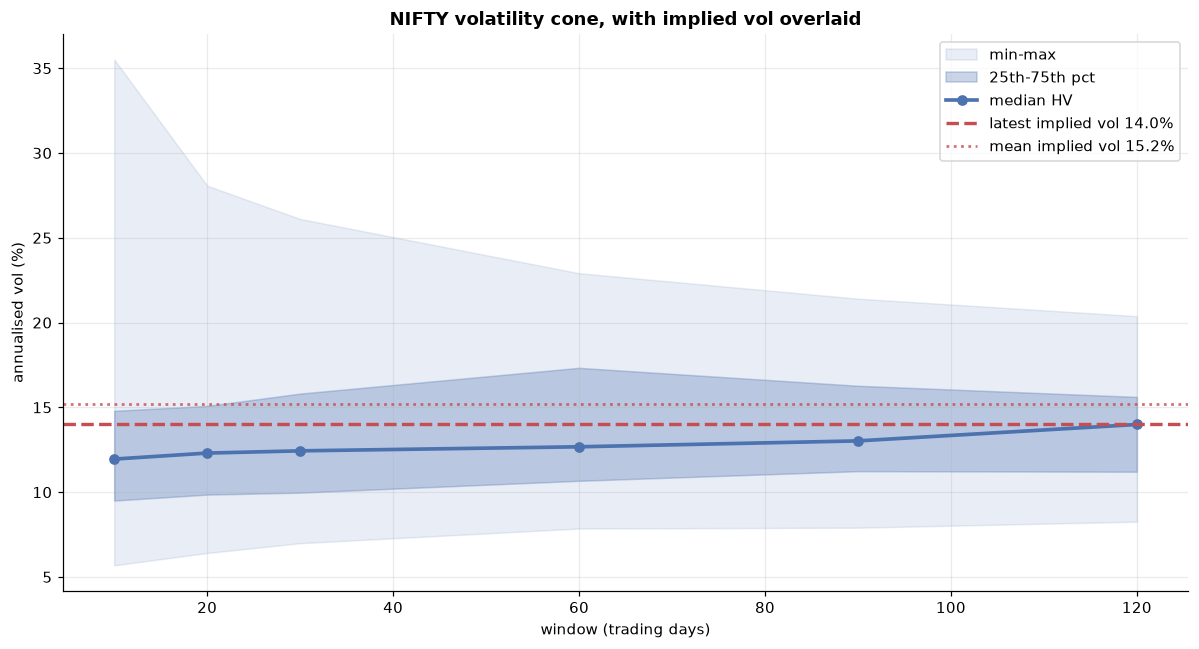

,min,p25,median,p75,max,current
window_days,,,,,,
10,5.68,9.50,11.95,14.80,35.52,10.53
20,6.41,9.86,12.30,15.09,28.07,11.24
30,6.99,9.97,12.44,15.81,26.11,10.69
60,7.85,10.67,12.68,17.33,22.91,12.88
90,7.90,11.24,13.02,16.27,21.41,16.81
120,8.26,11.21,13.99,15.62,20.38,18.27


In [11]:
spot = vp.load_spot()
cone = vol.vol_cone(spot, windows=(10, 20, 30, 60, 90, 120))

fig, ax = plt.subplots(figsize=(11, 6))
x = cone.index.astype(int)
ax.fill_between(x, cone["min"] * 100, cone["max"] * 100, color=C_HV, alpha=0.12, label="min-max")
ax.fill_between(x, cone["p25"] * 100, cone["p75"] * 100, color=C_HV, alpha=0.30, label="25th-75th pct")
ax.plot(x, cone["median"] * 100, color=C_HV, lw=2.4, marker="o", label="median HV")
ax.axhline(df.iv.iloc[-1] * 100, color=C_IV, ls="--", lw=2.2,
           label=f"latest implied vol {df.iv.iloc[-1]*100:.1f}%")
ax.axhline(df.iv.mean() * 100, color=C_IV, ls=":", lw=1.8, alpha=0.8,
           label=f"mean implied vol {df.iv.mean()*100:.1f}%")
ax.set_xlabel("window (trading days)"); ax.set_ylabel("annualised vol (%)")
ax.set_title("NIFTY volatility cone, with implied vol overlaid")
ax.legend()
plt.tight_layout(); plt.show()
(cone * 100).round(2)

## 10. Was the premium *justified*? IV vs what actually happened

`IV − HV` is knowable at trade time. `IV − RV` is only knowable afterwards, and
it is the number that says whether the option was genuinely overpriced. A
positive `IV − RV` is money the option seller kept.

**This section is hindsight.** It is not a signal.

1,125 observations whose option life has completed


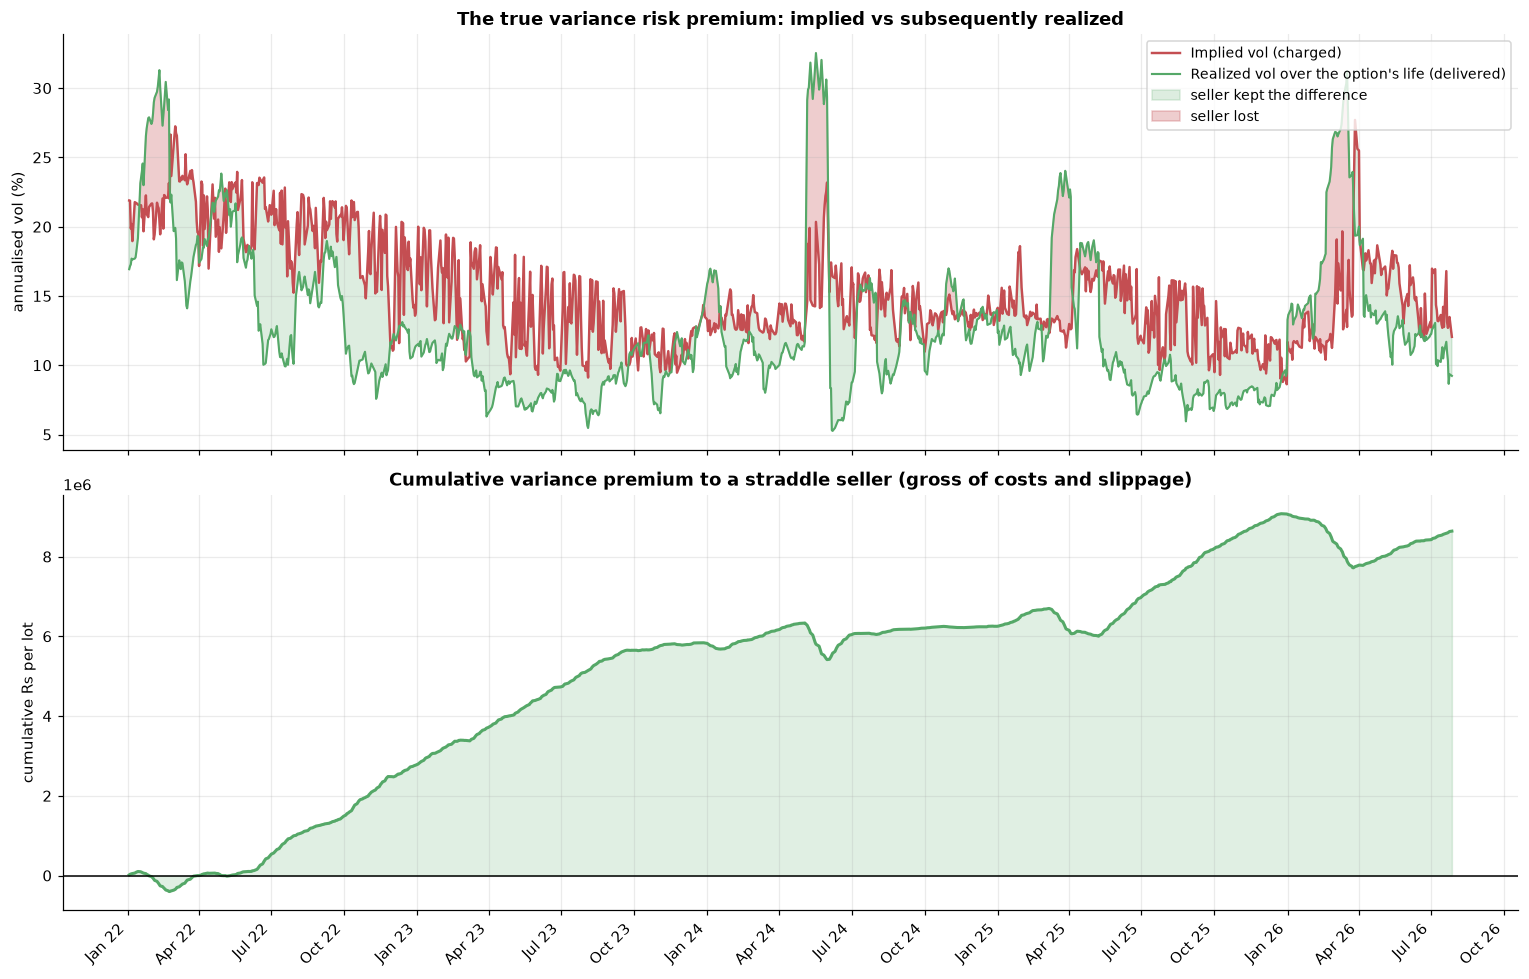

IV exceeded subsequent RV on 78.6% of days
mean IV - RV: +2.39 vol points
mean per-lot: Rs +7,679   worst day: Rs -66,633


In [12]:
settled = df.dropna(subset=["rv_forward"]).copy()
print(f"{len(settled):,} observations whose option life has completed")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(settled.date, settled.iv * 100, color=C_IV, lw=1.6, label="Implied vol (charged)")
ax1.plot(settled.date, settled.rv_forward * 100, color=C_RV, lw=1.4,
         label="Realized vol over the option's life (delivered)")
ax1.fill_between(settled.date, settled.rv_forward * 100, settled.iv * 100,
                 where=settled.iv >= settled.rv_forward, color=C_RV, alpha=0.2,
                 interpolate=True, label="seller kept the difference")
ax1.fill_between(settled.date, settled.rv_forward * 100, settled.iv * 100,
                 where=settled.iv < settled.rv_forward, color=C_IV, alpha=0.28,
                 interpolate=True, label="seller lost")
ax1.set_ylabel("annualised vol (%)")
ax1.set_title("The true variance risk premium: implied vs subsequently realized")
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(settled.date, settled.vrp_rupees.cumsum(), color=C_RV, lw=2)
ax2.axhline(0, color="black", lw=1.0)
ax2.fill_between(settled.date, 0, settled.vrp_rupees.cumsum(),
                 color=C_RV, alpha=0.18)
ax2.set_ylabel("cumulative Rs per lot")
ax2.set_title("Cumulative variance premium to a straddle seller (gross of costs and slippage)")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print(f"IV exceeded subsequent RV on {100*(settled.vrp_vol_points>0).mean():.1f}% of days")
print(f"mean IV - RV: {settled.vrp_vol_points.mean()*100:+.2f} vol points")
print(f"mean per-lot: Rs {settled.vrp_rupees.mean():+,.0f}   worst day: Rs {settled.vrp_rupees.min():+,.0f}")

## 11. The two premiums compared

`IV − HV` (backward) and `IV − RV` (forward) answer different questions. Where
they disagree is where the backward-looking gap misled.

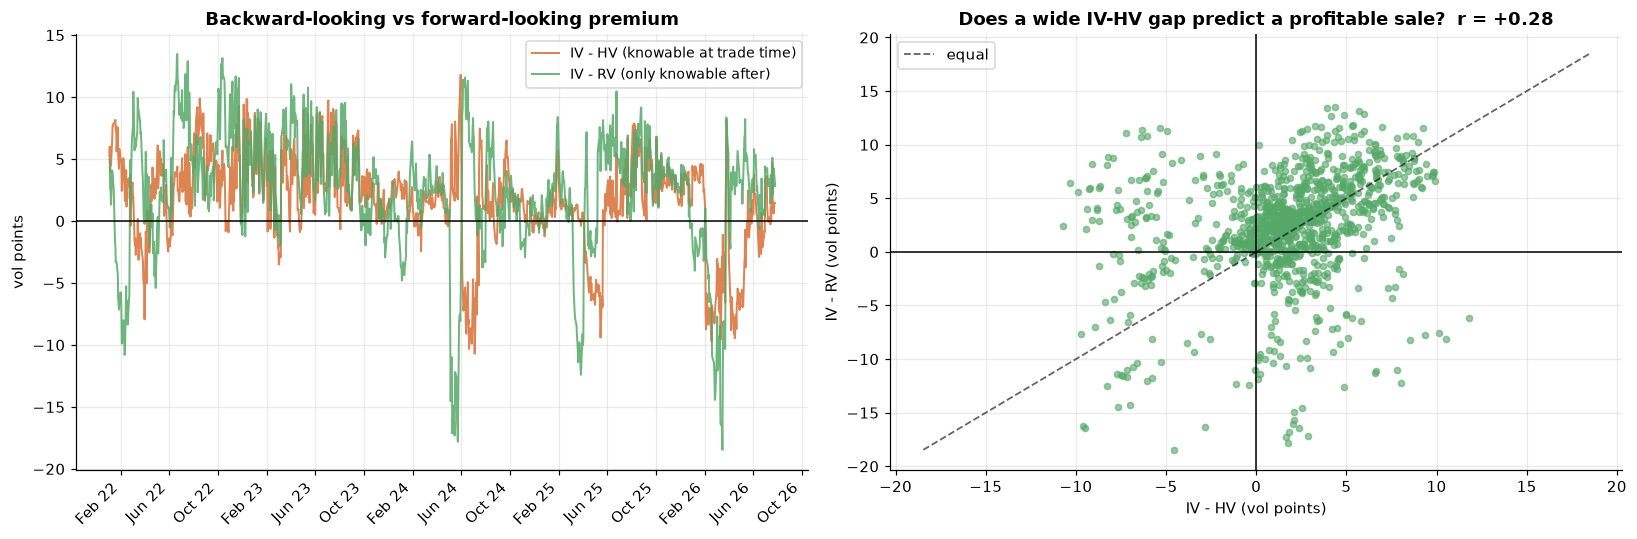

When IV-HV was narrowest (bottom quartile): mean IV-RV = +0.79 vol pts
When IV-HV was widest  (top quartile):     mean IV-RV = +4.75 vol pts


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(settled.date, settled.iv_minus_hv * 100, color=C_GAP, lw=1.3,
         label="IV - HV (knowable at trade time)")
ax1.plot(settled.date, settled.vrp_vol_points * 100, color=C_RV, lw=1.3, alpha=0.85,
         label="IV - RV (only knowable after)")
ax1.axhline(0, color="black", lw=1.0)
ax1.set_ylabel("vol points"); ax1.set_title("Backward-looking vs forward-looking premium")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2.scatter(settled.iv_minus_hv * 100, settled.vrp_vol_points * 100, s=16, alpha=0.6, color=C_RV)
ax2.axhline(0, color="black", lw=1.0); ax2.axvline(0, color="black", lw=1.0)
lim = max(abs(settled.iv_minus_hv * 100).max(), abs(settled.vrp_vol_points * 100).max())
ax2.plot([-lim, lim], [-lim, lim], "k--", lw=1.2, alpha=0.6, label="equal")
ax2.set_xlabel("IV - HV (vol points)"); ax2.set_ylabel("IV - RV (vol points)")
r = settled.iv_minus_hv.corr(settled.vrp_vol_points)
ax2.set_title(f"Does a wide IV-HV gap predict a profitable sale?  r = {r:+.2f}")
ax2.legend()
plt.tight_layout(); plt.show()

q1 = settled[settled.iv_minus_hv <= settled.iv_minus_hv.quantile(0.25)]
q4 = settled[settled.iv_minus_hv >= settled.iv_minus_hv.quantile(0.75)]
print(f"When IV-HV was narrowest (bottom quartile): mean IV-RV = {q1.vrp_vol_points.mean()*100:+.2f} vol pts")
print(f"When IV-HV was widest  (top quartile):     mean IV-RV = {q4.vrp_vol_points.mean()*100:+.2f} vol pts")

## 12. Seasonality and the biggest days

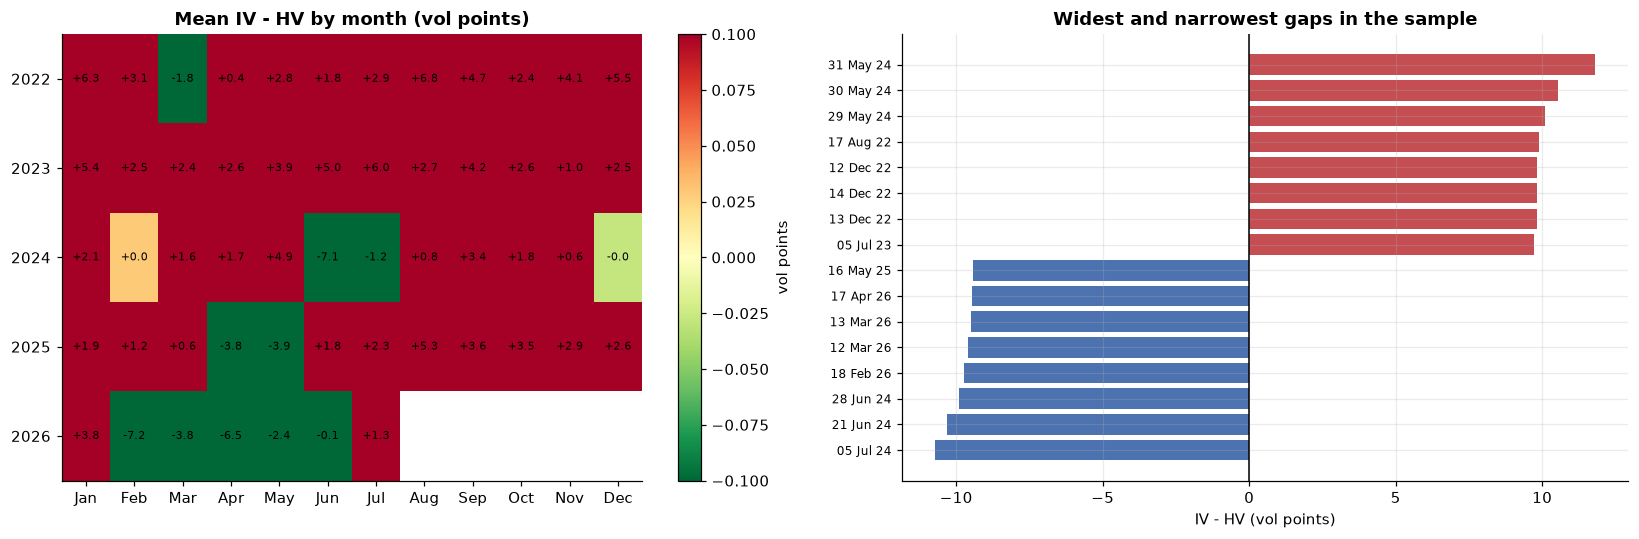

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

df["year"] = df.date.dt.year
df["month"] = df.date.dt.month
pivot = df.pivot_table(index="year", columns="month", values="iv_minus_hv", aggfunc="mean") * 100
im = ax1.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto",
                vmin=-abs(pivot.values).max(), vmax=abs(pivot.values).max())
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(pivot.columns)])
ax1.set_yticks(range(len(pivot.index))); ax1.set_yticklabels(pivot.index)
ax1.set_title("Mean IV - HV by month (vol points)")
ax1.grid(False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if np.isfinite(v):
            ax1.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=7.5)
plt.colorbar(im, ax=ax1, label="vol points")

extremes = pd.concat([df.nlargest(8, "iv_minus_hv"), df.nsmallest(8, "iv_minus_hv")])
extremes = extremes.sort_values("iv_minus_hv")
cols = np.where(extremes.iv_minus_hv >= 0, C_IV, C_HV)
ax2.barh(extremes.date.dt.strftime("%d %b %y"), extremes.iv_minus_hv * 100, color=cols)
ax2.axvline(0, color="black", lw=1.0)
ax2.set_xlabel("IV - HV (vol points)")
ax2.set_title("Widest and narrowest gaps in the sample")
ax2.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

---

# Why does the gap exist?

The data above shows a persistent, positive, mean-reverting gap. Here are the
mechanisms that produce it, and what in this notebook supports or tests each.

### 1. Risk compensation — the variance risk premium

This is the dominant explanation. An option seller is short gamma and short
vega: their losses arrive precisely when the market crashes, which is when money
is worth most and when they can least afford it. Nobody takes that exposure at
its actuarially fair price, so options trade *above* the value implied by the
volatility that actually shows up. The excess is a risk premium, not a
mispricing — it is payment for bearing crash risk.

*Supporting evidence here:* section 10 shows implied vol exceeding subsequently
realized vol most of the time, with the seller's cumulative gain punctuated by
sharp losses. That asymmetric shape — many small wins, occasional large losses —
is the signature of an earned risk premium rather than a free lunch.

### 2. HV looks backward; IV looks forward

Historical volatility is a summary of a window that has already closed. Implied
volatility prices what might happen next. Before a scheduled event — the Union
Budget, an RBI policy decision, election counting day, a Fed meeting — implied
vol rises while historical vol, computed over a calm past window, does not. The
gap widens mechanically, then collapses after the event as realized volatility
catches up or the uncertainty resolves.

*Supporting evidence here:* the spikes in section 2 cluster around event dates,
and the extremes table in section 12 lists them.

### 3. Jump risk that has not happened yet

A 30-day historical window containing no crash reports low volatility. Implied
volatility still embeds the probability of a crash, because one is always
possible. HV can only measure the tail it has already seen; IV prices the tail
it hasn't. In a calm sample the gap is therefore structurally positive — and
this is exactly the state in which selling volatility looks most attractive and
is most dangerous.

### 4. Volatility mean-reverts, so the gap is regime-dependent

This is the most actionable finding, and section 7 measures it directly: the gap
is *negatively* correlated with the level of historical volatility. After a calm
stretch, the market prices reversion upward and IV sits well above HV. After a
volatility spike, implied vol frequently sits *below* trailing historical vol,
because the market expects the storm to pass. So "IV > HV" is not a constant —
it is a function of where volatility currently is.

### 5. Structural demand for optionality in India

Indian institutions are structurally long equity and buy index puts to hedge.
That is persistent one-way demand that lifts put implied vol. Separately, India
runs the world's largest listed options market by contract count, with very
heavy retail buying of short-dated out-of-the-money options. Persistent net
demand for optionality supports implied vol above the statistically fair level.

*Note on measurement:* this demand shows up as **skew** — OTM puts trade at
materially higher vol than the forward. This notebook deliberately interpolates
the smile to the forward rather than averaging strikes around it, so the ATM
number is not contaminated by skew. Averaging would have reported a larger
premium that was partly just the skew.

### 6. Part of the gap is a modelling choice, not a market fact

Section 6 shows the measured premium changing by a meaningful margin depending
on which historical estimator is used. Gap-blind estimators (Parkinson,
Garman-Klass) read NIFTY's volatility low, because a large share of NIFTY's
movement arrives as overnight gaps on global cues — and a lower HV
mechanically produces a larger apparent premium. Yang-Zhang is used as the
default here for that reason. Anyone quoting a single "NIFTY VRP" number without
stating the estimator is quoting an artefact along with the signal.

In [15]:
# Quantifying the mechanisms that are directly testable.
print("=" * 74)
print("MECHANISM 4 - is the gap regime-dependent?")
print("=" * 74)
slope, intercept = np.polyfit(df.hv * 100, df.iv_minus_hv * 100, 1)
print(f"  regression: (IV-HV) = {intercept:+.2f} {slope:+.3f} x HV      [vol points]")
print(f"  correlation(HV, gap) = {df.hv.corr(df.iv_minus_hv):+.3f}")
print(f"  HV level at which the gap crosses zero: {-intercept/slope:.1f}%")
print(f"  -> below that, IV usually exceeds HV; above it, IV is often below HV")

print()
print("=" * 74)
print("MECHANISM 6 - how much of the premium is the estimator choice?")
print("=" * 74)
for m, lab in zip(methods, labels):
    g = (df.iv - df[m]).mean() * 100
    print(f"  {lab:16s}  mean gap {g:+5.2f} vol points")
spread = max((df.iv - df[m]).mean() for m in methods) - min((df.iv - df[m]).mean() for m in methods)
print(f"  spread across estimators: {spread*100:.2f} vol points "
      f"(~Rs {(spread * df.straddle_vega * df.lot_size).mean():,.0f}/lot)")

print()
print("=" * 74)
print("MECHANISM 1 - is the seller's payoff shaped like a risk premium?")
print("=" * 74)
w = settled.vrp_rupees
print(f"  win rate:            {100*(w>0).mean():.1f}%")
print(f"  mean win:            Rs {w[w>0].mean():+,.0f}")
print(f"  mean loss:           Rs {w[w<0].mean():+,.0f}")
print(f"  worst single day:    Rs {w.min():+,.0f}")
print(f"  skewness of payoff:  {w.skew():+.2f}   (negative = many small wins, rare large losses)")

MECHANISM 4 - is the gap regime-dependent?
  regression: (IV-HV) = +8.66 -0.516 x HV      [vol points]
  correlation(HV, gap) = -0.628
  HV level at which the gap crosses zero: 16.8%
  -> below that, IV usually exceeds HV; above it, IV is often below HV

MECHANISM 6 - how much of the premium is the estimator choice?
  Close-to-close    mean gap +2.10 vol points
  Parkinson         mean gap +4.76 vol points
  Garman-Klass      mean gap +4.79 vol points
  Yang-Zhang        mean gap +1.71 vol points
  spread across estimators: 3.08 vol points (~Rs 10,056/lot)

MECHANISM 1 - is the seller's payoff shaped like a risk premium?
  win rate:            78.6%
  mean win:            Rs +14,264
  mean loss:           Rs -16,476
  worst single day:    Rs -66,633
  skewness of payoff:  -1.35   (negative = many small wins, rare large losses)


---

## Caveats — what this does not establish

- **Settle prices, not tradeable prices.** NSE settle prices are daily marks. A
  real seller crosses a bid-ask spread, pays brokerage and STT, and posts
  margin. Every rupee figure here is gross of all of that, and for short-dated
  options those costs are a large share of the premium.
- **No liquidity filter is applied by default.** The model can filter on open
  interest and volume, but the run above does not. Untraded strikes carry
  exchange-calculated settle prices, and inverting those produces a
  plausible-looking implied vol with no trading behind it.
- **Cumulative seller P&L is not a backtest.** It overlaps positions daily,
  never rolls or hedges, ignores margin and assumes every position is held to
  expiry. It illustrates the shape of the premium, not a strategy.
- **The sample is short and regime-specific.** It covers a period without a
  2008- or 2020-scale crash. The variance risk premium is compensation for
  exactly that kind of event, so a sample that excludes one will overstate how
  attractive selling volatility is.
- **Lot size is taken from NSE where published**, and falls back to a constant
  for older dates. Check `lot_size_source` before relying on rupee figures from
  the legacy period.

In [16]:
print("Rows by lot-size source (rupee figures are exact only where 'nse'):")
print(df.lot_size_source.value_counts().to_string())
print()
print("Lot sizes seen in the sample:", sorted(df.lot_size.unique()))
print()
print(f"Median strikes used for the ATM interpolation: {df.n_quotes.median():.0f}")
print(f"Days with fewer than 3 usable strikes: {(df.n_quotes < 3).sum()}")

Rows by lot-size source (rupee figures are exact only where 'nse'):
lot_size_source
fallback    613
nse         515

Lot sizes seen in the sample: [np.float64(25.0), np.float64(65.0), np.float64(75.0)]

Median strikes used for the ATM interpolation: 27
Days with fewer than 3 usable strikes: 0
